<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/DBSCAN_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DBSCAN is a density-based clustering algorithm that groups data points that are closely packed together and marks outliers as noise based on their density in the feature space. It identifies clusters as dense regions in the data space separated by areas of lower density. Unlike K-Means or hierarchical clustering which assumes clusters are compact and spherical, DBSCAN perform well in handling real-world data irregularities such as:

Arbitrary-Shaped Clusters: Clusters can take any shape not just circular or convex.
Noise and Outliers: It effectively identifies and handles noise points without assigning them to any cluster.

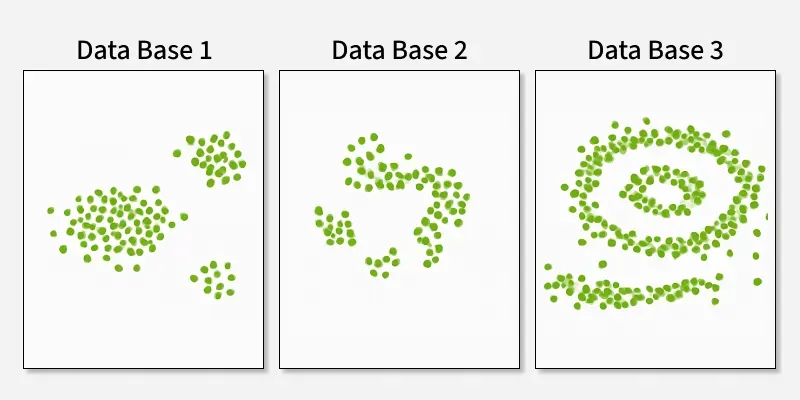

The figure above shows a data set with clustering algorithms: K-Means and Hierarchical handling compact, spherical clusters with varying noise tolerance while DBSCAN manages arbitrary-shaped clusters and noise handling.

Key Parameters in DBSCAN
1. eps: This defines the radius of the neighborhood around a data point. If the distance between two points is less than or equal to eps they are considered neighbors. A common method to determine eps is by analyzing the k-distance graph. Choosing the right eps is important:If eps is too small most points will be classified as noise.
If eps is too large clusters may merge and the algorithm may fail to distinguish between them.
2. MinPts: This is the minimum number of points required within the eps radius to form a dense region. A general rule of thumb is to set MinPts >= D+1 where D is the number of dimensions in the dataset.

For most cases a minimum value of MinPts = 3 is recommended.

How Does DBSCAN Work?
DBSCAN works by categorizing data points into three types:

Core points which have a sufficient number of neighbors within a specified radius (eplison)
Border points which are near core points but lack enough neighbors to be core points themselves
Noise points which do not belong to any cluster.
By iteratively expanding clusters from core points and connecting density-reachable points, DBSCAN forms clusters without relying on rigid assumptions about their shape or size.

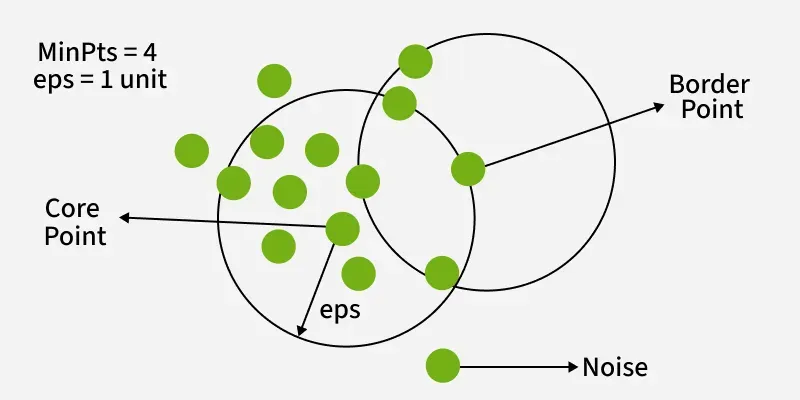

Steps in the DBSCAN Algorithm
Identify Core Points: For each point in the dataset count the number of points within its eps neighborhood. If the count meets or exceeds MinPts mark the point as a core point.
Form Clusters: For each core point that is not already assigned to a cluster create a new cluster. Recursively find all density-connected points i.e points within the eps radius of the core point and add them to the cluster.
Density Connectivity: Two points a and b are density-connected if there exists a chain of points where each point is within the eps radius of the next and at least one point in the chain is a core point. This chaining process ensures that all points in a cluster are connected through a series of dense regions.
Label Noise Points: After processing all points any point that does not belong to a cluster is labeled as noise.
Implementation of DBSCAN Algorithm In Python
Here we’ll use the Python library sklearn to compute DBSCAN and matplotlib.pyplot library for visualizing clusters.

Step 1: Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

Step 2: Preparing Dataset
We will create a dataset of 4 clusters using make_blob. The dataset have 300 points that are grouped into 4 visible clusters.

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)

Step 3: Applying DBSCAN Clustering
Now we apply DBSCAN clustering on our data, count it and visualize it using the matplotlib library.

eps=0.3: The radius to look for neighboring points.
min_samples: Minimum number of points required to form a dense region a cluster.
labels: Cluster numbers for each point. -1 means the point is considered noise.

['y', 'b', 'g', 'r']


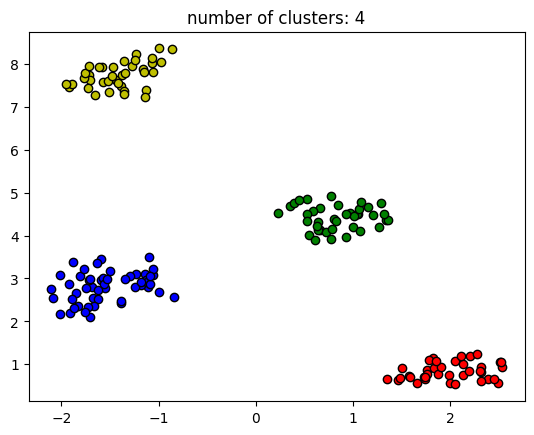

In [3]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:

        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

As shown in above output image cluster are shown in different colours like yellow, blue, green and red.

Step 4: Evaluation Metrics For DBSCAN Algorithm In Machine Learning
We will use the Silhouette score and Adjusted rand score for evaluating clustering algorithms.

Silhouette's score is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point i is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.
Absolute Rand Score is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery.

In [5]:
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31


Black points represent outliers. By changing the eps and the MinPts we can change the cluster configuration.

When Should We Use DBSCAN Over K-Means Clustering?
DBSCAN and K-Means are both clustering algorithms that group together data that have the same characteristic. However they work on different principles and are suitable for different types of data. We prefer to use DBSCAN when the data is not spherical in shape or the number of classes is not known beforehand.

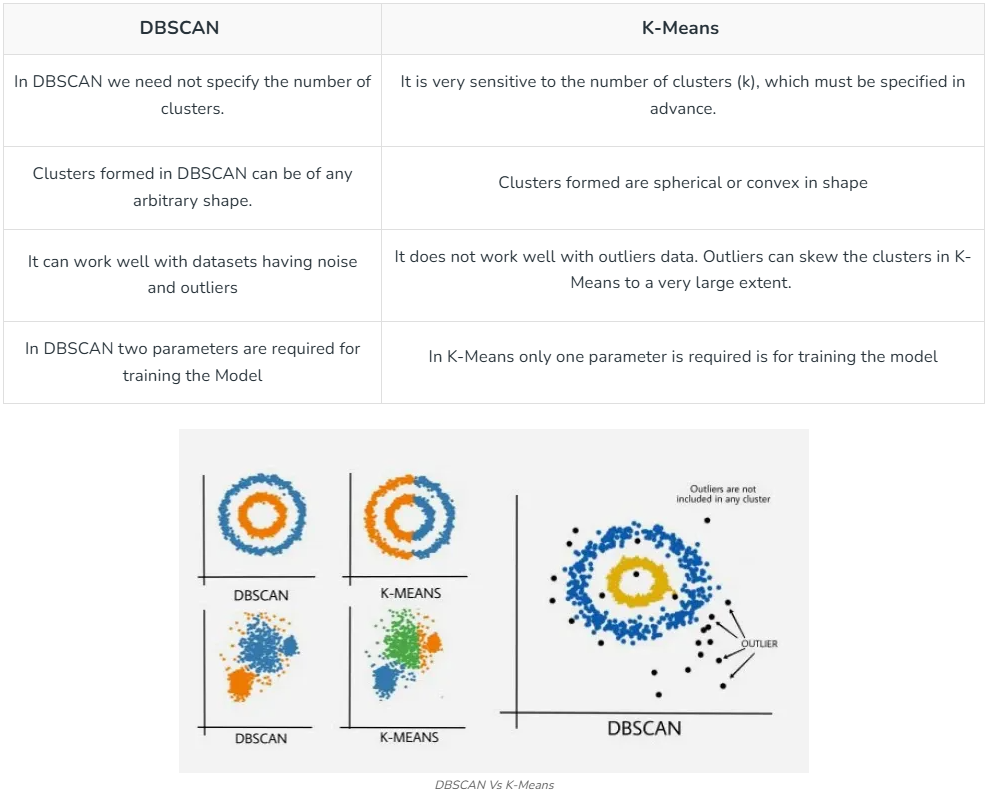

As it can identify clusters of arbitrary shapes and effectively handle noise. K-Means on the other hand is better suited for data with well-defined, spherical clusters and is less effective with noise or complex cluster structures.